In [ ]:
#Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
#Step 2: Load Dataset

df = pd.read_csv("House Price India.csv")

df.head()

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
0,6762810635,42491,4,2.50,2920,4000,1.5,0,0,5,...,1909,0,122004,52.8878,-114.470,2470,4000,2,51,1400000
1,6762810998,42491,5,2.75,2910,9480,1.5,0,0,3,...,1939,0,122004,52.8852,-114.468,2940,6600,1,53,1200000
2,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,...,2001,0,122005,52.9532,-114.321,3350,42847,3,76,838000
3,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,...,1929,0,122006,52.9047,-114.485,2060,4500,1,51,805000
4,6762813105,42491,3,2.50,2600,4750,1.0,0,0,4,...,1951,0,122007,52.9133,-114.590,2380,4750,1,67,790000


In [ ]:
#Step 3: Check Dataset Information
print(df.shape)

print(df.info())

print(df.describe())

print(df.isnull().sum())

(14619, 23)
<class 'pandas.DataFrame'>
RangeIndex: 14619 entries, 0 to 14618
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     14619 non-null  int64  
 1   Date                                   14619 non-null  int64  
 2   number of bedrooms                     14619 non-null  int64  
 3   number of bathrooms                    14619 non-null  float64
 4   living area                            14619 non-null  int64  
 5   lot area                               14619 non-null  int64  
 6   number of floors                       14619 non-null  float64
 7   waterfront present                     14619 non-null  int64  
 8   number of views                        14619 non-null  int64  
 9   condition of the house                 14619 non-null  int64  
 10  grade of the house                     14619 non-null  int64  
 11  A

In [4]:
df.drop("id", axis=1, inplace=True)

In [5]:
df.drop("Date", axis=1, inplace=True)

In [6]:
print(df.columns)

Index(['number of bedrooms', 'number of bathrooms', 'living area', 'lot area',
       'number of floors', 'waterfront present', 'number of views',
       'condition of the house', 'grade of the house',
       'Area of the house(excluding basement)', 'Area of the basement',
       'Built Year', 'Renovation Year', 'Postal Code', 'Lattitude',
       'Longitude', 'living_area_renov', 'lot_area_renov',
       'Number of schools nearby', 'Distance from the airport', 'Price'],
      dtype='str')


In [7]:
y = df["Price"]

In [8]:
X = df.drop("Price", axis=1)

In [9]:
X = pd.get_dummies(X, drop_first=True)

In [10]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

model.add(Dense(32, activation='relu'))

model.add(Dense(16, activation='relu'))

model.add(Dense(1))

c:\Users\Lenovo\OneDrive\Desktop\Advance DSL\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
#Step 10: Compile Model
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [16]:
#Step 11: Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 30314672128.0000 - mae: 105239.1484 - val_loss: 26331545600.0000 - val_mae: 104348.1094
Epoch 2/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 30226227200.0000 - mae: 105110.5391 - val_loss: 26275469312.0000 - val_mae: 103895.5000
Epoch 3/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 30289582080.0000 - mae: 104799.8594 - val_loss: 26435309568.0000 - val_mae: 105092.5703
Epoch 4/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 30118973440.0000 - mae: 104886.4922 - val_loss: 26361970688.0000 - val_mae: 104734.7969
Epoch 5/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 30090448896.0000 - mae: 104718.4609 - val_loss: 26251976704.0000 - val_mae: 104119.7500
Epoch 6/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 30075852800.0000 - mae: 104856.9453 - val_loss: 26203060224.0000 - val_mae: 103821.1484
Epoch 7/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 29955383296.0000 - mae: 104237.5234 - val_loss: 2656

In [17]:
loss, mae = model.evaluate(X_test, y_test)

print("Test Loss :", loss)

print("Test MAE :", mae)

92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 31747422208.0000 - mae: 106343.0156
Test Loss : 31747422208.0
Test MAE : 106343.015625


In [18]:
y_pred = model.predict(X_test)

92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [19]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)

print("MSE :", mse)

print("RMSE :", rmse)

print("R2 Score :", r2)

MAE : 106343.015625
MSE : 31747426304.0
RMSE : 178178.07470056467
R2 Score : 0.7854846715927124


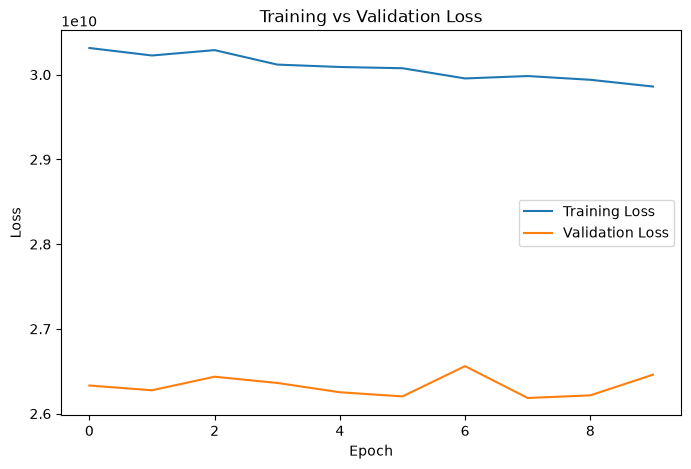

In [21]:
#Step 15: Plot Training Loss
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

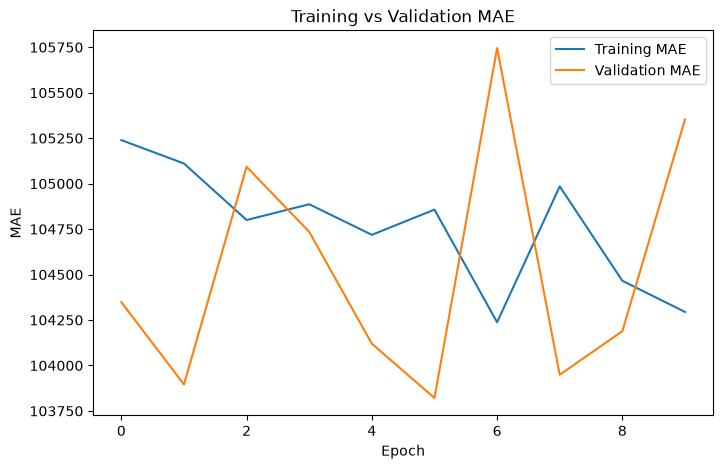

In [22]:
#Step 16: Plot MAE
plt.figure(figsize=(8,5))

plt.plot(history.history['mae'], label='Training MAE')

plt.plot(history.history['val_mae'], label='Validation MAE')

plt.xlabel("Epoch")

plt.ylabel("MAE")

plt.title("Training vs Validation MAE")

plt.legend()

plt.show()

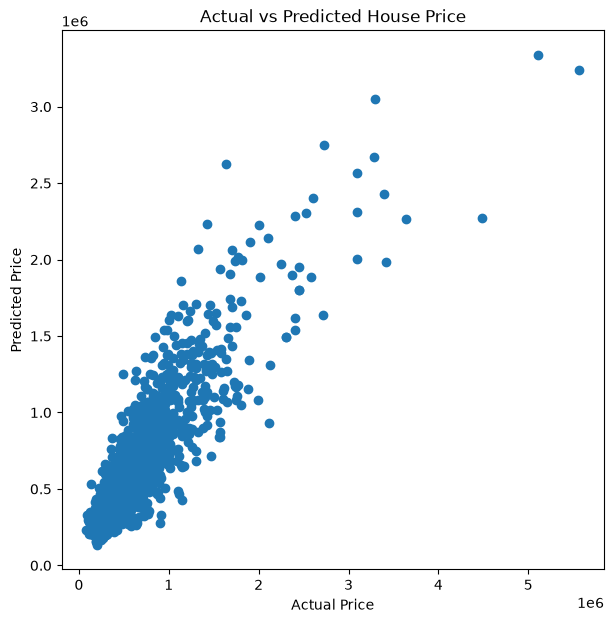

In [23]:
#Step 17: Actual vs Predicted
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Price")

plt.show()

In [24]:
#Step 18: Predict a Single House
sample = X_test[0].reshape(1,-1)

prediction = model.predict(sample)

print("Predicted House Price =", prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Predicted House Price = 498038.1
